<a href="https://colab.research.google.com/github/Abhisek963/machineLearning_Lab/blob/main/26March02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (2240, 29)
Missing before: 1348
Shape after cleaning: (916, 32)
X shape: (916, 40)


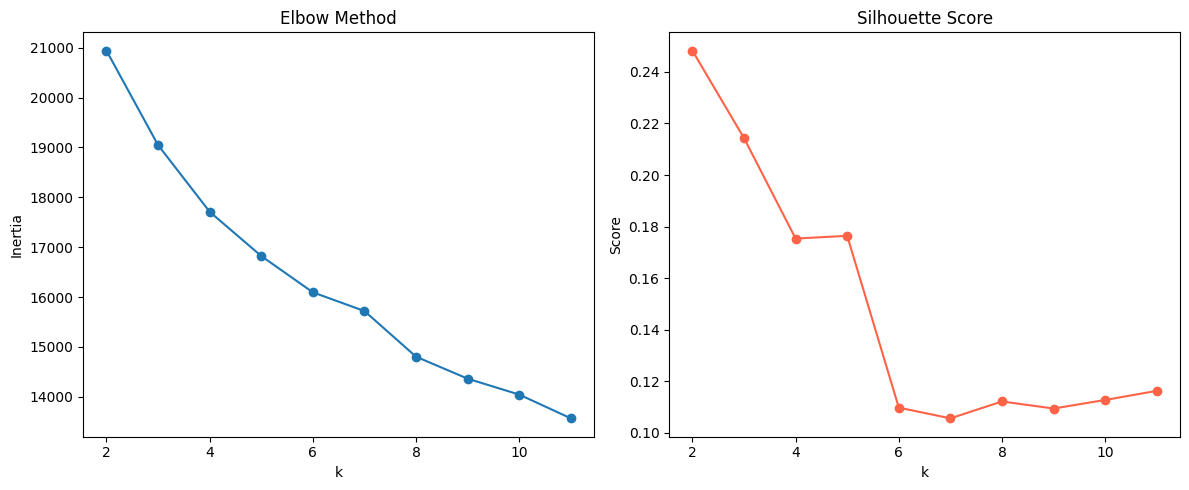


Best k = 3  (silhouette = 0.248)

Cluster counts:
 Cluster
0     95
1    466
2    355
Name: count, dtype: int64

Cluster Profiles:
            Age    Income  TotalSpend  TotalBuys  TenureDays  CmpAccepted
Cluster                                                                 
0        52.87  81428.99     1630.82      19.86     4658.35         2.43
1        53.09  37310.47      127.87       6.62     4630.02         0.15
2        58.13  67037.39      991.48      18.61     4694.03         0.31


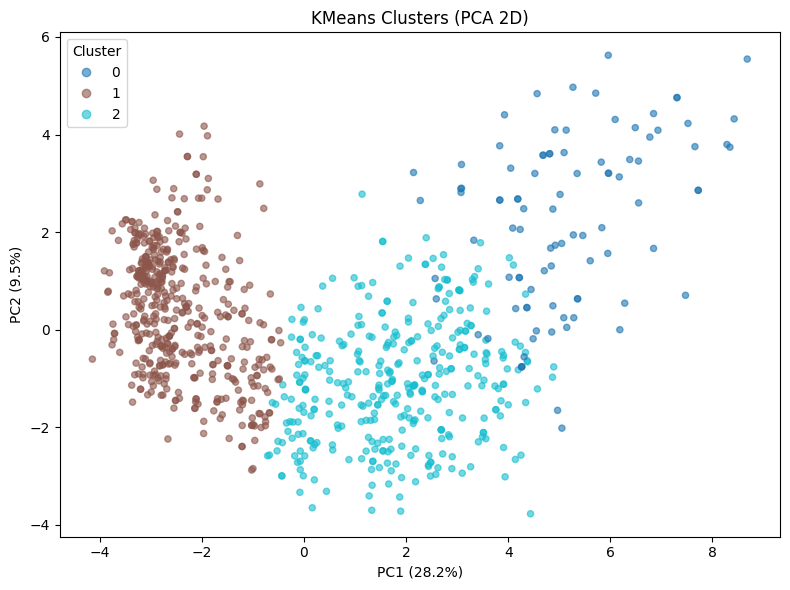


#---- Naive Bayes ----#
              precision    recall  f1-score   support

           0       0.36      1.00      0.53        17
           1       1.00      0.98      0.99        96
           2       0.95      0.58      0.72        71

    accuracy                           0.83       184
   macro avg       0.77      0.85      0.75       184
weighted avg       0.92      0.83      0.84       184



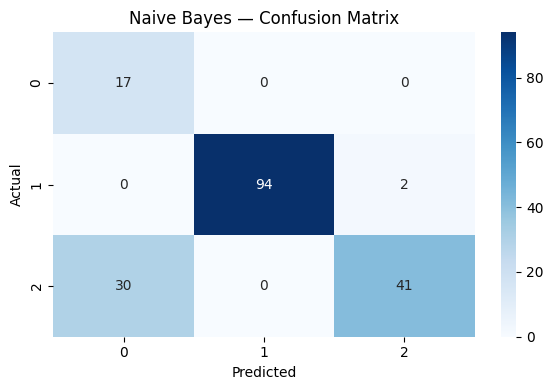


#---- Logistic Regression ----#
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      0.98      0.99        96
           2       0.97      1.00      0.99        71

    accuracy                           0.99       184
   macro avg       0.99      0.99      0.99       184
weighted avg       0.99      0.99      0.99       184



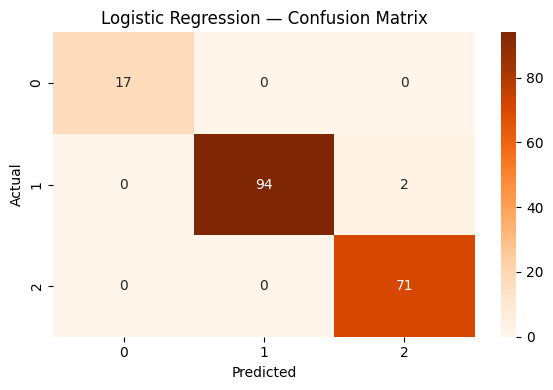

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# ── 1. Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv("new.csv")
print("Shape:", df.shape)

df.drop(columns=["ID"], inplace=True, errors="ignore")

# ── 2. Feature Engineering ────────────────────────────────────────────────────
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")
df["TenureDays"]  = (pd.Timestamp.today() - df["Dt_Customer"]).dt.days
df.drop(columns=["Dt_Customer"], inplace=True)

df["Age"]          = 2024 - df["Year_Birth"]
df["TotalSpend"]   = df[["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]].sum(axis=1)
df["TotalBuys"]    = df["NumWebPurchases"] + df["NumCatalogPurchases"] + df["NumStorePurchases"]
df["CmpAccepted"]  = df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]].sum(axis=1)

# ── 3. Missing Values ─────────────────────────────────────────────────────────
print("Missing before:", df.isna().sum().sum())
df["Income"] = df["Income"].fillna(df["Income"].median())
df.dropna(inplace=True)
print("Shape after cleaning:", df.shape)

# ── 4. Column Types ───────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# ── 5. Preprocessing Pipeline ─────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols),
], remainder="drop")

X = preprocessor.fit_transform(df)
print("X shape:", X.shape)

# ── 6. Find Best k ────────────────────────────────────────────────────────────
inertias   = []
sil_scores = []
K_range    = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(K_range, inertias, marker="o")
ax1.set_title("Elbow Method")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax2.plot(K_range, sil_scores, marker="o", color="tomato")
ax2.set_title("Silhouette Score")
ax2.set_xlabel("k")
ax2.set_ylabel("Score")
plt.tight_layout()
plt.savefig("elbow_silhouette.png")
plt.show()

# ── 7. Final KMeans ───────────────────────────────────────────────────────────
best_k = 3
print(f"\nBest k = {best_k}  (silhouette = {max(sil_scores):.3f})")

km_final      = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X)

df["Cluster"] = cluster_labels
print("\nCluster counts:\n", df["Cluster"].value_counts().sort_index())

# ── 8. Cluster Profiles ───────────────────────────────────────────────────────
profile_cols = [c for c in ["Age","Income","TotalSpend","TotalBuys","TenureDays","CmpAccepted"] if c in df.columns]
print("\nCluster Profiles:\n", df.groupby("Cluster")[profile_cols].mean().round(2))

# ── 9. PCA Plot ───────────────────────────────────────────────────────────────
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap="tab10", alpha=0.6, s=20)
plt.legend(*sc.legend_elements(), title="Cluster")
plt.title("KMeans Clusters (PCA 2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.savefig("clusters_pca.png")
plt.show()

# ── 10. Naive Bayes vs Logistic Regression ────────────────────────────────────
# BUG FIX: transform df without the Cluster column using the already-fit preprocessor
X_clf = preprocessor.transform(df.drop(columns=["Cluster"]))
X_train, X_test, y_train, y_test = train_test_split(X_clf, cluster_labels, test_size=0.2, random_state=42)

print("\n#---- Naive Bayes ----#")
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print(classification_report(y_test, y_pred_nb))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt="d", cmap="Blues")
plt.title("Naive Bayes — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("cm_naive_bayes.png")
plt.show()

print("\n#---- Logistic Regression ----#")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Oranges")
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("cm_logistic.png")
plt.show()